<a href="https://colab.research.google.com/github/mbc2009/MKsim_HL/blob/codex%2Fview-repository-contents/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from tqdm import tqdm


# New Section

In [2]:
import numpy as np
from dataclasses import dataclass, field



@dataclass
class data_block():
  row: int
  column: int
  b:int     = 2     # 单元素字节数 (单位: Byte/个) 默认 fp16 => b=2
  prec:int  = 16    # 数据精度
  @property
  def size(self):
    """计算数据总字节数"""
    return self.row * self.column * self.b # (单位: Byte)

@dataclass
class item_emb_class(data_block):
  K_emb: int     = int(2e3)      # 候选物品数
  dim_item: int    = 1024     # 物品维度
  row: int         = field(default_factory=lambda: int(item_emb_class.K_emb))
  column: int      = field(default_factory=lambda: int(item_emb_class.dim_item))

@dataclass
class user_emb_class(data_block):
  S: int           = int(8e3)    # 用户序列长
  dim_item: int    = 1024        # 物品维度
  dim_user: int    = 256         # 用户行为维度，这里修改为带类型提示的字段
  column: int      = field(default_factory=lambda: int(user_emb_class.dim_user + user_emb_class.dim_item))
  row: int         = field(default_factory=lambda: int(user_emb_class.S))


In [3]:
# @title
# 打印
if True:
  item_emb = item_emb_class()
  print(f"item_emb.row: {item_emb.row}")
  print(f"item_emb.column: {item_emb.column}")
  print(f"item_emb.size: {item_emb.size} Bytes\n")

  user_emb = user_emb_class()
  print(f"user_emb.row: {user_emb.row}")
  print(f"user_emb.column: {user_emb.column}")
  print(f"user_emb.size: {user_emb.size} Bytes")

item_emb.row: 2000
item_emb.column: 1024
item_emb.size: 4096000 Bytes

user_emb.row: 8000
user_emb.column: 1280
user_emb.size: 20480000 Bytes


In [4]:
# @title: T_trans Calculation

@dataclass
class Hardware():
  BW_eff:float = 11.5       # GB/s
  flit:int = 64           # Byte
  T_0 = 200               # ns
  num_agg: int  =  4     # unitless

def transfer_latency(data_trans,T_0=200):
  data_trans = data_trans         # Byte

  T_0  = Hardware.T_0              # ns
  BW_eff = Hardware.BW_eff
  flit = Hardware.flit

  T_total = T_0/1e6 + (int(data_trans/flit) * flit)/ (BW_eff * 1e9) * 1e3 # ms

  return T_total # ms

def T_end2end(num_trans,T_trans):
  return num_trans * T_trans # ms

In [5]:
# user emb transfer time latency

def T_trans_user_emb(should_print=False):
  user_emb = user_emb_class()
  if should_print:
    print(f'用户序列传输')
    print(f'用户序列长={user_emb.S:.0e}, 用户行为维数={user_emb.dim_user}, item维数={user_emb.dim_item}')
    print(f'T_0={Hardware.T_0},带宽={Hardware.BW_eff} GB/s, Flit={Hardware.flit}B')

  # part1: user action part
  num_fetch  = user_emb.row/ Hardware.num_agg
  size_fetch = user_emb.size/user_emb.row * (user_emb.dim_user/(user_emb.dim_user + user_emb.dim_item)) * Hardware.num_agg


  T_user_emb_1 = T_end2end(
      num_trans=num_fetch,
      T_trans=transfer_latency(size_fetch,Hardware.T_0)
  )

  # part2: item tensor
  num_fetch  = user_emb.row/ Hardware.num_agg
  size_fetch = user_emb.size/user_emb.row * (user_emb.dim_item/(user_emb.dim_user + user_emb.dim_item)) * Hardware.num_agg

  T_user_emb_2 = T_end2end(
      num_trans=num_fetch,
      T_trans=transfer_latency(size_fetch,Hardware.T_0)
  )

  # sun
  T_user_emb = T_user_emb_1 + T_user_emb_2
  if should_print:
    print(f'T_0={Hardware.T_0:.0f} ns  T={T_user_emb:.2f} ms')

  return T_user_emb


# item emb transfer time latency
def T_trans_item_emb(should_print=False):
  item_emb = item_emb_class()
  if should_print:
    print(f'物品emb传输') # Changed message to reflect item emb
    print(f'item维数={item_emb.dim_item}, 候选物品数={item_emb.K_emb}')
    print(f'T_0={Hardware.T_0},带宽={Hardware.BW_eff} GB/s, Flit={Hardware.flit}B')

  num_fetch  = item_emb.row/ Hardware.num_agg
  size_fetch = item_emb.size/item_emb.row  *  Hardware.num_agg
  T_item_emb_calculated = T_end2end(
      num_trans=num_fetch,
      T_trans=transfer_latency(size_fetch,Hardware.T_0)
  )
  if should_print:
    print(f'T_0={Hardware.T_0:.0f} ns  T={T_item_emb_calculated:.2f} ms')

  return T_item_emb_calculated # Renamed variable and fixed return value


In [6]:
Hardware.T_0 = 233

T_trans_user_emb(should_print=True)
T_trans_item_emb(should_print=True)

用户序列传输
用户序列长=8e+03, 用户行为维数=256, item维数=1024
T_0=233,带宽=11.5 GB/s, Flit=64B
T_0=233 ns  T=2.71 ms
物品emb传输
item维数=1024, 候选物品数=2000
T_0=233,带宽=11.5 GB/s, Flit=64B
T_0=233 ns  T=0.47 ms


0.4726739130434783

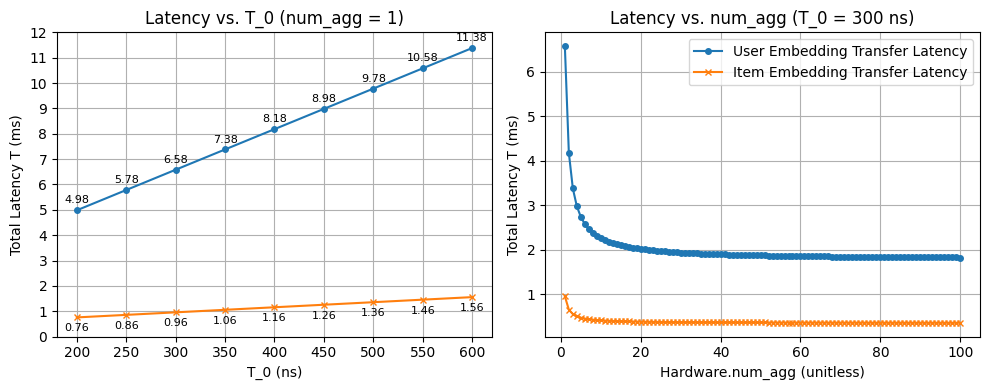

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# --------- Plot 1: T vs T_0 ---------
Hardware.num_agg = 1

T_0_values_plot1 = np.arange(200, 601, 50) # Range of T_0 from 200ns to 600ns
T_user_delays_plot1 = []
T_item_delays_plot1 = []

for T_0 in T_0_values_plot1:
    Hardware.T_0 = T_0
    T_user_delays_plot1.append(T_trans_user_emb())
    T_item_delays_plot1.append(T_trans_item_emb())

axes[0].plot(T_0_values_plot1, T_user_delays_plot1, label='User Embedding Transfer Latency', marker='o', markersize=4)
axes[0].plot(T_0_values_plot1, T_item_delays_plot1, label='Item Embedding Transfer Latency', marker='x', markersize=4)

axes[0].set_xlabel('T_0 (ns)')
axes[0].set_ylabel('Total Latency T (ms)')
axes[0].set_title(f'Latency vs. T_0 (num_agg = {Hardware.num_agg})')

# Annotate y-values for User Embedding Transfer Latency
for i, txt in enumerate(T_user_delays_plot1):
    axes[0].annotate(f'{txt:.2f}', (T_0_values_plot1[i], T_user_delays_plot1[i]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

# Annotate y-values for Item Embedding Transfer Latency
for i, txt in enumerate(T_item_delays_plot1):
    axes[0].annotate(f'{txt:.2f}', (T_0_values_plot1[i], T_item_delays_plot1[i]), textcoords="offset points", xytext=(0,-10), ha='center', fontsize=8)

axes[0].grid(True)

# Calculate min and max for y-ticks to ensure coverage
import math
min_y_plot1 = math.floor(min(min(T_user_delays_plot1), min(T_item_delays_plot1)))
max_y_plot1 = math.ceil(max(max(T_user_delays_plot1), max(T_item_delays_plot1)))
axes[0].set_yticks(np.arange(min_y_plot1, max_y_plot1 + 1, 1)) # Set y-axis to linear scale with increment of 1



# --------- Plot 2: T vs Hardware.num_agg ---------
num_agg_values_plot2 = np.arange(1, 101, 1) # Range of num_agg from 1 to 100
T_user_delays_plot2 = []
T_item_delays_plot2 = []

fixed_T_0_for_plot2 = 300 # ns
Hardware.T_0 = fixed_T_0_for_plot2

for current_num_agg in num_agg_values_plot2:
    Hardware.num_agg = current_num_agg
    T_user_delays_plot2.append(T_trans_user_emb())
    T_item_delays_plot2.append(T_trans_item_emb())

axes[1].plot(num_agg_values_plot2, T_user_delays_plot2, label='User Embedding Transfer Latency', marker='o', markersize=4)
axes[1].plot(num_agg_values_plot2, T_item_delays_plot2, label='Item Embedding Transfer Latency', marker='x', markersize=4)

axes[1].set_xlabel('Hardware.num_agg (unitless)')
axes[1].set_ylabel('Total Latency T (ms)')
axes[1].set_title(f'Latency vs. num_agg (T_0 = {fixed_T_0_for_plot2} ns)')
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()